# Hyperparameter tuning evaluation — model-style metrics

This notebook evaluates hyperparameter-tuning runs with the same core metrics as the normal model evaluation notebook, but in a lighter format.

It reports:

- `nDCG@1`, `nDCG@3`, and `nDCG@5`
- `Hit@1`, `Hit@3`, and `Hit@5`
- `Must-have Recall@1`, `Must-have Recall@3`, and `Must-have Recall@5`
- `Relevant Recall@3` and `Relevant Recall@5`
- returned equipment count
- fallback/full-text diagnostics for literature retrieval
- paired deltas against a selected baseline run

The notebook accepts both `.json` and `.jsonl` result files.

## Setup

Edit `RESULT_FILES` if your filenames differ. The default paths are written for your repository layout, where result files are usually in `data/processed`.

In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any

import pandas as pd

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 180)

In [2]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------

RESULT_FILES = {
    # No decomposition, no paper reranking, 12 papers
    "direct_no_rerank_12papers": "hyperparameter_tuning_15_results_no_paper_reranking_12papers.json",

    # No decomposition, paper reranking, 10 papers
    "direct_rerank_10papers": "hyperparameter_tuning_15_results_paper_reranked_10papers.json",

    # Decomposition, no paper reranking, 12 papers
    "decomposition_no_rerank_12papers_2workers": "hyperparameter_tuning_15_results_decomposition_paper_no_reranked_12papers_2workers.json",

    # Decomposition, paper reranking, 10 papers
    "decomposition_rerank_10papers_2workers": "hyperparameter_tuning_15_results_decomposition_paper_reranked_10papers_2workers.json",
}

# Choose the run used for paired delta comparisons.
# If this name is not found, the first available run is used automatically.
BASELINE_RUN = "direct_no_rerank_12papers"

# The notebook checks these directories, in order, for each configured filename.
SEARCH_DIRS = [
    Path("data/processed"),
    Path("../data/processed"),
    Path("."),
    Path("/mnt/data"),
]

OUTPUT_DIR = Path("data/evaluation/hyperparameter_tuning_model_metrics")
if not Path("data").exists() and Path("../data").exists():
    OUTPUT_DIR = Path("../data/evaluation/hyperparameter_tuning_model_metrics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: data/evaluation/hyperparameter_tuning_model_metrics


## Load `.json` / `.jsonl` results

The loader also handles resumed runs by keeping only the latest record per query, preferring completed records over failed records.

In [3]:
_SURROGATE_RE = re.compile(r"[\ud800-\udfff]")


def clean_text_for_utf8(value: Any) -> str:
    """Make text safe for CSV/LaTeX export after PDF extraction artifacts."""
    if value is None:
        return ""
    try:
        if pd.isna(value):
            return ""
    except (TypeError, ValueError):
        pass
    text = str(value)
    text = _SURROGATE_RE.sub("", text)
    return text.encode("utf-8", errors="ignore").decode("utf-8", errors="ignore")


def make_dataframe_utf8_safe(df: pd.DataFrame) -> pd.DataFrame:
    """Remove isolated surrogate characters from object/string columns before writing."""
    out = df.copy()
    for column in out.select_dtypes(include=["object", "string"]).columns:
        out[column] = out[column].map(lambda value: clean_text_for_utf8(value) if value is not None else value)
    return out


def safe_to_csv(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    make_dataframe_utf8_safe(df).to_csv(path, index=False, encoding="utf-8")


def filename_variants(filename: str) -> list[str]:
    path = Path(filename)
    variants = [str(path)]
    if path.suffix.lower() in {".json", ".jsonl"}:
        variants.append(str(path.with_suffix(".jsonl")))
        variants.append(str(path.with_suffix(".json")))
    return list(dict.fromkeys(variants))


def resolve_result_path(filename: str) -> Path | None:
    raw_path = Path(filename)
    if raw_path.exists():
        return raw_path

    for variant in filename_variants(filename):
        variant_path = Path(variant)
        if variant_path.exists():
            return variant_path
        for base_dir in SEARCH_DIRS:
            candidate = base_dir / variant_path.name
            if candidate.exists():
                return candidate
    return None


def _records_from_json_value(data: Any, path: Path) -> list[dict[str, Any]]:
    if isinstance(data, dict):
        return [data]
    if isinstance(data, list):
        if not all(isinstance(item, dict) for item in data):
            raise ValueError(f"Expected a list of JSON objects in {path}")
        return data
    raise ValueError(f"Expected JSON records in {path}, got {type(data).__name__}")


def load_jsonl(path: Path) -> list[dict[str, Any]]:
    records: list[dict[str, Any]] = []
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                data = json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Could not parse JSONL line {line_number} in {path}: {exc}") from exc
            records.extend(_records_from_json_value(data, path))
    if not records:
        raise ValueError(f"No records found in JSONL file: {path}")
    return records


def load_result_records(path: Path) -> list[dict[str, Any]]:
    path = Path(path)
    if path.suffix.lower() == ".jsonl":
        return load_jsonl(path)
    try:
        with path.open("r", encoding="utf-8", errors="ignore") as f:
            data = json.load(f)
        return _records_from_json_value(data, path)
    except json.JSONDecodeError:
        # Some progress-saving files have a .json suffix but contain JSONL records.
        return load_jsonl(path)


def record_time(record: dict[str, Any]) -> str:
    return (
        record.get("completed_at_utc")
        or record.get("failed_at_utc")
        or record.get("started_at_utc")
        or record.get("run_timestamp_utc")
        or ""
    )


def record_query_id(record: dict[str, Any]) -> str:
    query_id = record.get("input_query_id") or (record.get("input_raw_benchmark_item") or {}).get("query_id")
    if query_id:
        return str(query_id)
    query = record.get("original_query") or (record.get("input_raw_benchmark_item") or {}).get("problem_description")
    if query:
        return "query_" + normalize_text(str(query))[:120]
    return "unknown"


def record_key(record: dict[str, Any]) -> str:
    return (
        record.get("input_run_id")
        or record.get("input_query_id")
        or (record.get("input_raw_benchmark_item") or {}).get("query_id")
        or record.get("original_query")
        or json.dumps(record, sort_keys=True, default=str)[:500]
    )


def keep_latest_prefer_completed(records: list[dict[str, Any]]) -> list[dict[str, Any]]:
    grouped: dict[str, list[dict[str, Any]]] = defaultdict(list)
    for record in records:
        grouped[record_key(record)].append(record)

    cleaned = []
    for group in grouped.values():
        completed = [record for record in group if record.get("run_status") == "completed"]
        candidates = completed if completed else group
        cleaned.append(sorted(candidates, key=record_time)[-1])

    return sorted(cleaned, key=lambda record: (record_query_id(record), record_time(record)))

In [4]:
# Resolve, load, and de-duplicate all configured runs.

resolved_files: dict[str, Path] = {}
missing_files: dict[str, str] = {}
for run_name, filename in RESULT_FILES.items():
    path = resolve_result_path(filename)
    if path is None:
        missing_files[run_name] = filename
    else:
        resolved_files[run_name] = path

if missing_files:
    print("Missing configured files. Either move them into data/processed or edit RESULT_FILES:")
    for run_name, filename in missing_files.items():
        print(f"- {run_name}: {filename}")

if not resolved_files:
    raise FileNotFoundError("No result files were found. Update RESULT_FILES before continuing.")

results_by_run: dict[str, list[dict[str, Any]]] = {}
load_summary_rows = []
for run_name, path in resolved_files.items():
    raw_records = load_result_records(path)
    records = keep_latest_prefer_completed(raw_records)
    results_by_run[run_name] = records
    counts = Counter(record.get("run_status") or "unknown" for record in records)
    load_summary_rows.append({
        "run_name": run_name,
        "path": str(path),
        "raw_records": len(raw_records),
        "unique_records": len(records),
        "completed_records": counts.get("completed", 0),
        "failed_or_interrupted_records": len(records) - counts.get("completed", 0),
    })

load_summary_df = pd.DataFrame(load_summary_rows)
load_summary_df

,run_name,path,raw_records,unique_records,completed_records,failed_or_interrupted_records
0,direct_no_rerank_12papers,../data/processed/hyperparameter_tuning_15_results_no_paper_reranking_12papers.json,15,15,15,0
1,direct_rerank_10papers,../data/processed/hyperparameter_tuning_15_results_paper_reranked_10papers.json,15,15,15,0
2,decomposition_no_rerank_12papers_2workers,../data/processed/hyperparameter_tuning_15_results_decomposition_paper_no_reranked_12papers_2workers.json,15,15,15,0
3,decomposition_rerank_10papers_2workers,../data/processed/hyperparameter_tuning_15_results_decomposition_paper_reranked_10papers_2workers.json,15,15,15,0


## Matching equipment outputs to benchmark labels

The scoring below follows the normal evaluation notebook: benchmark labels are converted to graded relevance scores.

- `must_have` and `best_match` → relevance 3
- `acceptable_alternatives` → relevance 2
- `supporting_but_not_ideal` → relevance 1
- unmatched or clearly unsuitable outputs → relevance 0

In [6]:
def normalize_text(value: str | None) -> str:
    if not value:
        return ""
    value = clean_text_for_utf8(value).lower()
    value = value.replace("µ", "μ")
    value = value.replace("-", " ").replace("–", " ").replace("—", " ")
    value = value.replace("_", " ").replace("/", " ")
    value = re.sub(r"[^a-z0-9μ]+", " ", value)
    value = re.sub(r"\s+", " ", value).strip()
    return value


ABBREVIATION_EQUIVALENTS = {
    "dsc": ["differential scanning calorimeter", "differential scanning calorimetry"],
    "dma": ["dynamic mechanical analyzer", "dynamic mechanical analysis", "dynamic mechanical thermal analyzer", "dynamic mechanical thermal analysis"],
    "tga": ["thermogravimetric analyzer", "thermogravimetric analysis"],
    "afm": ["atomic force microscope", "atomic force microscopy"],
    "sem": ["scanning electron microscope", "scanning electron microscopy"],
    "tem": ["transmission electron microscope", "transmission electron microscopy"],
    "xrd": ["x ray diffractometer", "x ray diffraction", "x-ray diffractometer", "x-ray diffraction"],
    "xps": ["x ray photoelectron spectrometer", "x ray photoelectron spectroscopy", "x-ray photoelectron spectroscopy"],
    "ftir": ["fourier transform infrared spectrometer", "fourier transform infrared spectroscopy"],
    "nmr": ["nuclear magnetic resonance spectrometer", "nuclear magnetic resonance spectroscopy"],
    "lc ms": ["liquid chromatography mass spectrometry", "liquid chromatograph mass spectrometer"],
    "lc ms ms": ["liquid chromatography tandem mass spectrometer", "liquid chromatography tandem mass spectrometry", "lc tandem mass spectrometer"],
    "lcmsms": ["liquid chromatography tandem mass spectrometer", "liquid chromatography tandem mass spectrometry", "lc ms ms"],
    "gc ms": ["gas chromatography mass spectrometry", "gas chromatograph mass spectrometer"],
    "qcm d": ["quartz crystal microbalance with dissipation monitoring", "quartz crystal microbalance"],
    "uv vis": ["ultraviolet visible spectrophotometer", "uv visible spectrophotometer", "uv vis spectrophotometer"],
}


def unique_keep_order(values: list[str]) -> list[str]:
    seen: set[str] = set()
    output: list[str] = []
    for value in values:
        key = normalize_text(value)
        if key and key not in seen:
            seen.add(key)
            output.append(str(value))
    return output


def expand_terms_basic(terms: list[str]) -> list[str]:
    expanded = list(terms)
    term_norms = {normalize_text(term) for term in terms}
    for abbreviation, full_terms in ABBREVIATION_EQUIVALENTS.items():
        abbreviation_norm = normalize_text(abbreviation)
        full_norms = {normalize_text(term) for term in full_terms}
        if abbreviation_norm in term_norms or term_norms.intersection(full_norms):
            expanded.append(abbreviation)
            expanded.extend(full_terms)
    return unique_keep_order(expanded)


def expand_with_synonyms(terms: list[str], synonyms: dict[str, list[str]] | None) -> list[str]:
    expanded = expand_terms_basic(list(terms))
    synonyms = synonyms or {}
    normalized_terms = {normalize_text(term) for term in expanded}

    for key, values in synonyms.items():
        key_norm = normalize_text(key)
        values = values or []
        value_norms = {normalize_text(value) for value in values}

        if key_norm in normalized_terms:
            expanded.extend(values)
        if normalized_terms.intersection(value_norms):
            expanded.append(key)
            expanded.extend(values)

    return expand_terms_basic(unique_keep_order(expanded))


def expected_terms_by_label(benchmark_item: dict[str, Any]) -> dict[str, list[str]]:
    expected = benchmark_item.get("expected_equipment") or {}
    synonyms = benchmark_item.get("synonyms") or {}
    labels = {
        "must_have": expected.get("must_have") or [],
        "best_match": expected.get("best_match") or [],
        "acceptable_alternatives": expected.get("acceptable_alternatives") or [],
        "supporting_but_not_ideal": expected.get("supporting_but_not_ideal") or [],
        "clearly_not_suitable": expected.get("clearly_not_suitable") or [],
    }
    return {
        label: expand_with_synonyms([str(item) for item in terms], synonyms)
        for label, terms in labels.items()
    }


MATCH_LABEL_SCORES = {
    "must_have": 3,
    "best_match": 3,
    "acceptable_alternatives": 2,
    "supporting_but_not_ideal": 1,
    "clearly_not_suitable": 0,
    "no_match": 0,
}

MATCH_LABEL_NAMES = {
    "must_have": "must_have",
    "best_match": "best_match",
    "acceptable_alternatives": "acceptable_alternative",
    "supporting_but_not_ideal": "supporting_but_not_ideal",
    "clearly_not_suitable": "clearly_not_suitable",
    "no_match": "no_match",
}


def names_match(predicted: str, expected: str) -> bool:
    p = normalize_text(predicted)
    e = normalize_text(expected)
    if not p or not e:
        return False
    if p == e:
        return True

    if len(p) >= 8 and len(e) >= 8 and (p in e or e in p):
        return True

    p_tokens = set(p.split())
    e_tokens = set(e.split())
    if len(p_tokens) >= 2 and len(e_tokens) >= 2:
        overlap = len(p_tokens & e_tokens)
        smaller = min(len(p_tokens), len(e_tokens))
        if smaller >= 2 and overlap / smaller >= 0.8:
            return True

    return False


def prediction_names(equipment: dict[str, Any]) -> list[str]:
    names = []
    for key in ["equipment_name", "normalized_equipment_name"]:
        if equipment.get(key):
            names.append(str(equipment[key]))
    names.extend([str(value) for value in equipment.get("aliases", []) or []])
    return expand_terms_basic(unique_keep_order(names))


def match_equipment_to_expected(equipment: dict[str, Any], benchmark_item: dict[str, Any]) -> dict[str, Any]:
    expected_by_label = expected_terms_by_label(benchmark_item)
    predicted_names = prediction_names(equipment)

    label_order = [
        "must_have",
        "best_match",
        "acceptable_alternatives",
        "supporting_but_not_ideal",
        "clearly_not_suitable",
    ]

    best = {
        "match_label_raw": "no_match",
        "match_label": "no_match",
        "match_score": 0,
        "matched_prediction_name": None,
        "matched_expected_name": None,
        "matched_expected_key": None,
    }

    for label in label_order:
        for predicted in predicted_names:
            for expected in expected_by_label[label]:
                if names_match(predicted, expected):
                    score = MATCH_LABEL_SCORES[label]
                    if score > best["match_score"] or (
                        score == best["match_score"]
                        and best["match_label_raw"] != "must_have"
                        and label == "must_have"
                    ):
                        best = {
                            "match_label_raw": label,
                            "match_label": MATCH_LABEL_NAMES[label],
                            "match_score": score,
                            "matched_prediction_name": predicted,
                            "matched_expected_name": expected,
                            "matched_expected_key": normalize_text(expected),
                        }

    return best

## Metric functions

The main table uses the same core interpretation as the normal model evaluation. `Hit@k` is relaxed: it counts a hit when at least one item in the top `k` has relevance score `2` or higher. `strict_hit@k` requires relevance score `3`.

In [7]:
def extract_equipment_list(record: dict[str, Any]) -> list[dict[str, Any]]:
    equipment = record.get("aggregated_equipment")
    if isinstance(equipment, list):
        return [item for item in equipment if isinstance(item, dict)]

    # Fallback for older outputs with only subproblem-level equipment.
    collected = []
    for subproblem_result in record.get("subproblem_results") or []:
        pipeline_result = subproblem_result.get("pipeline_result") or {}
        for item in pipeline_result.get("query_relevant_equipment") or []:
            if isinstance(item, dict):
                collected.append(item)
    return collected


def dcg(relevances: list[float], k: int) -> float:
    return sum((2**rel - 1) / math.log2(index + 1) for index, rel in enumerate(relevances[:k], start=1))


def ideal_relevances(benchmark_item: dict[str, Any], k: int) -> list[int]:
    expected = expected_terms_by_label(benchmark_item)
    rels: list[int] = []
    seen: set[str] = set()
    for label, relevance in [
        ("must_have", 3),
        ("best_match", 3),
        ("acceptable_alternatives", 2),
        ("supporting_but_not_ideal", 1),
    ]:
        for term in expected.get(label, []):
            key = normalize_text(term)
            if key and key not in seen:
                seen.add(key)
                rels.append(relevance)
    if not rels:
        rels = [3]
    return sorted(rels, reverse=True)[:k]


def expected_keys_for_labels(benchmark_item: dict[str, Any], labels: list[str]) -> set[str]:
    expected = expected_terms_by_label(benchmark_item)
    keys: set[str] = set()
    for label in labels:
        for term in expected.get(label, []):
            key = normalize_text(term)
            if key:
                keys.add(key)
    return keys


def matched_expected_keys(
    matches: list[dict[str, Any]],
    k: int,
    labels: list[str] | None = None,
    minimum_score: int | None = None,
) -> set[str]:
    keys = set()
    for match in matches[:k]:
        label_ok = labels is None or match.get("match_label_raw") in labels
        score_ok = minimum_score is None or match.get("match_score", 0) >= minimum_score
        if label_ok and score_ok and match.get("matched_expected_key"):
            keys.add(match["matched_expected_key"])
    return keys


def sum_counter_dicts(dicts: list[dict[str, int] | None]) -> dict[str, int]:
    counter = Counter()
    for d in dicts:
        if d:
            counter.update(d)
    return dict(counter)


def paper_reranking_enabled_for_record(record: dict[str, Any]) -> bool | None:
    flags = []
    for subproblem_result in record.get("subproblem_results") or []:
        pipeline_result = subproblem_result.get("pipeline_result") or {}
        summary = pipeline_result.get("paper_reranking_summary") or {}
        if "paper_reranking_enabled" in summary:
            flags.append(bool(summary.get("paper_reranking_enabled")))
    return any(flags) if flags else None


def source_summary_for_record(record: dict[str, Any]) -> dict[str, Any]:
    summaries = []
    for subproblem_result in record.get("subproblem_results") or []:
        pipeline_result = subproblem_result.get("pipeline_result") or {}
        summary = pipeline_result.get("paper_retrieval_summary") or {}
        if summary:
            summaries.append(summary)

    numeric_keys = [
        "num_papers_attempted",
        "num_papers_with_chunks",
        "num_full_text_success",
        "num_fallback_used",
        "num_skipped",
        "num_pdf_used",
        "num_html_used",
        "num_ar5iv_used",
        "num_abstract_fallback_used",
        "num_tldr_metadata_fallback_used",
        "num_metadata_fallback_used",
    ]

    if not summaries:
        return {
            **{key: None for key in numeric_keys},
            "full_text_success_fraction": None,
            "fallback_fraction": None,
            "skipped_fraction": None,
            "used_source_type_counts": {},
            "fallback_source_type_counts": {},
        }

    out = {key: sum(summary.get(key, 0) or 0 for summary in summaries) for key in numeric_keys}
    attempted = out["num_papers_attempted"] or 0
    out["full_text_success_fraction"] = out["num_full_text_success"] / attempted if attempted else None
    out["fallback_fraction"] = out["num_fallback_used"] / attempted if attempted else None
    out["skipped_fraction"] = out["num_skipped"] / attempted if attempted else None
    out["used_source_type_counts"] = sum_counter_dicts([summary.get("used_source_type_counts") for summary in summaries])
    out["fallback_source_type_counts"] = sum_counter_dicts([summary.get("fallback_source_type_counts") for summary in summaries])
    return out


def count_evidence_items(equipment_list: list[dict[str, Any]]) -> tuple[int, int]:
    evidence_quotes = 0
    papers = 0
    for item in equipment_list:
        evidence_quotes += len(item.get("evidence_text") or [])
        papers += len(item.get("supporting_papers") or [])
    return evidence_quotes, papers

In [8]:
def score_records(records: list[dict[str, Any]], run_name: str, k_values=(1, 3, 5)) -> pd.DataFrame:
    rows = []
    for record in records:
        query_id = record_query_id(record)
        benchmark_item = record.get("input_raw_benchmark_item") or {}
        equipment_list = extract_equipment_list(record)
        source = source_summary_for_record(record)
        status = record.get("run_status") or record.get("status") or "unknown"
        evidence_quote_count, supporting_paper_count = count_evidence_items(equipment_list)

        row = {
            "run_name": run_name,
            "query_id": query_id,
            "query_type": benchmark_item.get("query_type"),
            "case_type": benchmark_item.get("case_type"),
            "run_status": status,
            "used_decomposition": record.get("used_decomposition"),
            "paper_reranking_enabled": paper_reranking_enabled_for_record(record),
            "num_subproblems_run": record.get("num_subproblems_run"),
            "num_returned_equipment": len(equipment_list),
            "has_returned_equipment": len(equipment_list) > 0,
            "num_evidence_quotes": evidence_quote_count,
            "num_supporting_papers": supporting_paper_count,
            "original_query": record.get("original_query") or benchmark_item.get("problem_description"),
            **source,
        }

        if status != "completed" or not benchmark_item:
            row.update({
                "top1_equipment": equipment_list[0].get("equipment_name") if equipment_list else None,
                "top1_output_score": None,
                "top1_match_label": "missing_benchmark_or_not_completed" if not benchmark_item else "run_failed",
                "best_output_score_any_rank": None,
                "best_match_label_any_rank": "missing_benchmark_or_not_completed" if not benchmark_item else "run_failed",
                "error": record.get("error"),
                "match_scores": None,
                "match_labels": None,
                "matched_expected_names": None,
            })
            for k in k_values:
                row[f"ndcg_at_{k}"] = None
                row[f"hit_at_{k}"] = None
                row[f"strict_hit_at_{k}"] = None
                row[f"must_have_recall_at_{k}"] = None
                row[f"relevant_recall_at_{k}"] = None
                row[f"clearly_not_suitable_at_{k}"] = None
            rows.append(row)
            continue

        matches = [match_equipment_to_expected(equipment, benchmark_item) for equipment in equipment_list]
        match_scores = [match["match_score"] for match in matches]
        match_labels = [match["match_label"] for match in matches]
        raw_match_labels = [match["match_label_raw"] for match in matches]

        top1_equipment = equipment_list[0].get("equipment_name") if equipment_list else None
        top1_score = match_scores[0] if match_scores else 0
        top1_label = match_labels[0] if match_labels else "no_equipment_returned"
        best_score = max(match_scores) if match_scores else 0
        best_label = match_labels[match_scores.index(best_score)] if match_scores else "no_equipment_returned"

        must_have_keys = expected_keys_for_labels(benchmark_item, ["must_have"])
        relevant_keys = expected_keys_for_labels(benchmark_item, ["must_have", "best_match", "acceptable_alternatives"])

        row.update({
            "top1_equipment": top1_equipment,
            "top1_output_score": top1_score,
            "top1_match_label": top1_label,
            "best_output_score_any_rank": best_score,
            "best_match_label_any_rank": best_label,
            "error": None,
            "match_scores": match_scores,
            "match_labels": raw_match_labels,
            "matched_expected_names": [match.get("matched_expected_name") for match in matches],
        })

        for k in k_values:
            topk_scores = match_scores[:k]
            ideal = ideal_relevances(benchmark_item, k)
            ideal_dcg = dcg(ideal, k)
            row[f"ndcg_at_{k}"] = dcg(topk_scores, k) / ideal_dcg if ideal_dcg > 0 else 0.0
            row[f"hit_at_{k}"] = any(score >= 2 for score in topk_scores)
            row[f"strict_hit_at_{k}"] = any(score >= 3 for score in topk_scores)

            matched_must_have = matched_expected_keys(matches, k, labels=["must_have"])
            matched_relevant = matched_expected_keys(matches, k, minimum_score=2)
            row[f"must_have_recall_at_{k}"] = len(matched_must_have) / len(must_have_keys) if must_have_keys else None
            row[f"relevant_recall_at_{k}"] = len(matched_relevant) / len(relevant_keys) if relevant_keys else None
            row[f"clearly_not_suitable_at_{k}"] = any(label == "clearly_not_suitable" for label in raw_match_labels[:k])

        rows.append(row)

    return pd.DataFrame(rows)


query_score_df = pd.concat(
    [score_records(records, run_name) for run_name, records in results_by_run.items()],
    ignore_index=True,
)

query_score_df = query_score_df.sort_values(["query_id", "run_name"]).reset_index(drop=True)

preview_cols = [
    "run_name", "query_id", "query_type", "run_status", "num_returned_equipment",
    "top1_equipment", "top1_match_label", "ndcg_at_3", "hit_at_3",
    "must_have_recall_at_3", "relevant_recall_at_3", "fallback_fraction",
]
query_score_df[preview_cols].head(20)

,run_name,query_id,query_type,run_status,num_returned_equipment,top1_equipment,top1_match_label,ndcg_at_3,hit_at_3,must_have_recall_at_3,relevant_recall_at_3,fallback_fraction
0,decomposition_no_rerank_12papers_2workers,PET_packaging_barrier,broad_diagnostic,completed,14,scanning electron microscope,no_match,0.234639,True,0.200000,0.111111,0.782609
1,decomposition_rerank_10papers_2workers,PET_packaging_barrier,broad_diagnostic,completed,8,CIELAB color measurement system,no_match,0.530721,True,0.400000,0.222222,0.700000
2,direct_no_rerank_12papers,PET_packaging_barrier,broad_diagnostic,completed,4,oxygen transmission rate tester,no_match,0.530721,True,0.200000,0.222222,0.833333
3,direct_rerank_10papers,PET_packaging_barrier,broad_diagnostic,completed,4,oxygen transmission rate tester,no_match,0.530721,True,0.400000,0.222222,1.000000
4,decomposition_no_rerank_12papers_2workers,acoustic_particles_diagnostic,method_selection,completed,17,microfluidic chip,no_match,0.000000,False,0.000000,0.000000,0.739130
5,decomposition_rerank_10papers_2workers,acoustic_particles_diagnostic,method_selection,completed,6,standing surface acoustic wave (SSAW) microfluidic device,must_have,0.765361,True,0.333333,0.125000,1.000000
6,direct_no_rerank_12papers,acoustic_particles_diagnostic,method_selection,completed,3,surface acoustic wave (SAW) microfluidic chip,must_have,1.000000,True,0.666667,0.375000,0.666667
7,direct_rerank_10papers,acoustic_particles_diagnostic,method_selection,completed,5,optical tweezers,no_match,0.530721,True,0.333333,0.125000,0.900000
8,decomposition_no_rerank_12papers_2workers,afm-grease-microstructure,specific,completed,1,atomic force microscope,must_have,0.469279,True,0.333333,0.333333,1.000000
9,decomposition_rerank_10papers_2workers,afm-grease-microstructure,specific,completed,2,atomic force microscope,must_have,0.469279,True,0.333333,0.333333,0.700000


## Main overall comparison

This is the main table to use for choosing the best hyperparameter setting. Means are reported together with standard deviations for the most important query-level metrics.

In [9]:
def summarize_runs(df: pd.DataFrame) -> pd.DataFrame:
    completed = df[df["run_status"] == "completed"].copy()
    grouped = completed.groupby("run_name", dropna=False)
    summary = grouped.agg(
        n_queries=("query_id", "nunique"),
        avg_returned_equipment=("num_returned_equipment", "mean"),
        std_returned_equipment=("num_returned_equipment", "std"),
        mean_ndcg_at_1=("ndcg_at_1", "mean"),
        std_ndcg_at_1=("ndcg_at_1", "std"),
        mean_ndcg_at_3=("ndcg_at_3", "mean"),
        std_ndcg_at_3=("ndcg_at_3", "std"),
        mean_ndcg_at_5=("ndcg_at_5", "mean"),
        std_ndcg_at_5=("ndcg_at_5", "std"),
        hit_rate_at_1=("hit_at_1", "mean"),
        hit_rate_at_3=("hit_at_3", "mean"),
        hit_rate_at_5=("hit_at_5", "mean"),
        strict_hit_rate_at_1=("strict_hit_at_1", "mean"),
        strict_hit_rate_at_3=("strict_hit_at_3", "mean"),
        strict_hit_rate_at_5=("strict_hit_at_5", "mean"),
        must_have_recall_at_1=("must_have_recall_at_1", "mean"),
        must_have_recall_at_3=("must_have_recall_at_3", "mean"),
        must_have_recall_at_5=("must_have_recall_at_5", "mean"),
        relevant_recall_at_3=("relevant_recall_at_3", "mean"),
        relevant_recall_at_5=("relevant_recall_at_5", "mean"),
        clearly_not_suitable_rate_at_3=("clearly_not_suitable_at_3", "mean"),
        mean_fallback_fraction=("fallback_fraction", "mean"),
        mean_full_text_success_fraction=("full_text_success_fraction", "mean"),
        avg_evidence_quotes=("num_evidence_quotes", "mean"),
        avg_supporting_papers=("num_supporting_papers", "mean"),
    ).reset_index()

    return summary.sort_values("mean_ndcg_at_3", ascending=False)


overall_summary_df = summarize_runs(query_score_df)
overall_summary_df

,run_name,n_queries,avg_returned_equipment,std_returned_equipment,mean_ndcg_at_1,std_ndcg_at_1,mean_ndcg_at_3,std_ndcg_at_3,mean_ndcg_at_5,std_ndcg_at_5,hit_rate_at_1,hit_rate_at_3,hit_rate_at_5,strict_hit_rate_at_1,strict_hit_rate_at_3,strict_hit_rate_at_5,must_have_recall_at_1,must_have_recall_at_3,must_have_recall_at_5,relevant_recall_at_3,relevant_recall_at_5,clearly_not_suitable_rate_at_3,mean_fallback_fraction,mean_full_text_success_fraction,avg_evidence_quotes,avg_supporting_papers
2,direct_no_rerank_12papers,15,2.466667,1.245946,0.666667,0.487950,0.487961,0.305649,0.373301,0.227522,0.666667,0.800000,0.800000,0.666667,0.733333,0.733333,0.204762,0.242857,0.242857,0.217857,0.217857,0.0,0.798485,0.201515,5.533333,3.533333
1,decomposition_rerank_10papers_2workers,15,5.666667,5.327378,0.571429,0.485954,0.408621,0.344727,0.353465,0.298745,0.600000,0.666667,0.666667,0.533333,0.600000,0.600000,0.154762,0.183333,0.183333,0.125635,0.133042,0.0,0.703000,0.297000,11.600000,8.733333
3,direct_rerank_10papers,15,2.066667,1.533747,0.488889,0.501848,0.405538,0.337221,0.314937,0.255486,0.466667,0.600000,0.600000,0.466667,0.600000,0.600000,0.107143,0.183333,0.183333,0.118783,0.126190,0.0,0.786667,0.213333,4.800000,3.066667
0,decomposition_no_rerank_12papers_2workers,15,6.266667,6.029294,0.485714,0.500146,0.360111,0.355837,0.304858,0.306676,0.466667,0.600000,0.600000,0.400000,0.533333,0.533333,0.107143,0.145238,0.163095,0.148228,0.170635,0.0,0.781930,0.218070,14.666667,9.066667


In [10]:
# Compact thesis-friendly table.
# This keeps the same core metrics as the normal-model evaluation, without all diagnostic columns.

thesis_table_df = overall_summary_df[[
    "run_name",
    "n_queries",
    "avg_returned_equipment",
    "mean_ndcg_at_3",
    "std_ndcg_at_3",
    "hit_rate_at_1",
    "hit_rate_at_3",
    "must_have_recall_at_3",
    "relevant_recall_at_3",
    "mean_fallback_fraction",
    "mean_full_text_success_fraction",
]].copy()

thesis_table_df

,run_name,n_queries,avg_returned_equipment,mean_ndcg_at_3,std_ndcg_at_3,hit_rate_at_1,hit_rate_at_3,must_have_recall_at_3,relevant_recall_at_3,mean_fallback_fraction,mean_full_text_success_fraction
2,direct_no_rerank_12papers,15,2.466667,0.487961,0.305649,0.666667,0.800000,0.242857,0.217857,0.798485,0.201515
1,decomposition_rerank_10papers_2workers,15,5.666667,0.408621,0.344727,0.600000,0.666667,0.183333,0.125635,0.703000,0.297000
3,direct_rerank_10papers,15,2.066667,0.405538,0.337221,0.466667,0.600000,0.183333,0.118783,0.786667,0.213333
0,decomposition_no_rerank_12papers_2workers,15,6.266667,0.360111,0.355837,0.466667,0.600000,0.145238,0.148228,0.781930,0.218070


## Query-type breakdown

This helps check whether a run only performs well because it is better on one specific question type.

In [11]:
by_query_type_df = (
    query_score_df[query_score_df["run_status"] == "completed"]
    .groupby(["run_name", "query_type"], dropna=False)
    .agg(
        n_queries=("query_id", "nunique"),
        avg_returned_equipment=("num_returned_equipment", "mean"),
        mean_ndcg_at_3=("ndcg_at_3", "mean"),
        std_ndcg_at_3=("ndcg_at_3", "std"),
        hit_rate_at_1=("hit_at_1", "mean"),
        hit_rate_at_3=("hit_at_3", "mean"),
        must_have_recall_at_3=("must_have_recall_at_3", "mean"),
        relevant_recall_at_3=("relevant_recall_at_3", "mean"),
        clearly_not_suitable_rate_at_3=("clearly_not_suitable_at_3", "mean"),
        mean_fallback_fraction=("fallback_fraction", "mean"),
    )
    .reset_index()
    .sort_values(["query_type", "mean_ndcg_at_3"], ascending=[True, False])
)

by_query_type_df

,run_name,query_type,n_queries,avg_returned_equipment,mean_ndcg_at_3,std_ndcg_at_3,hit_rate_at_1,hit_rate_at_3,must_have_recall_at_3,relevant_recall_at_3,clearly_not_suitable_rate_at_3,mean_fallback_fraction
3,decomposition_rerank_10papers_2workers,broad_diagnostic,5,8.4,0.468795,0.361027,0.6,0.8,0.196667,0.134444,0.0,0.635000
9,direct_rerank_10papers,broad_diagnostic,5,2.2,0.412289,0.388365,0.4,0.6,0.196667,0.113889,0.0,0.860000
6,direct_no_rerank_12papers,broad_diagnostic,5,2.4,0.340784,0.322770,0.4,0.6,0.156667,0.094444,0.0,0.763636
0,decomposition_no_rerank_12papers_2workers,broad_diagnostic,5,8.8,0.307264,0.410491,0.2,0.6,0.156667,0.067222,0.0,0.750203
7,direct_no_rerank_12papers,method_selection,5,2.8,0.602875,0.418348,0.8,0.8,0.366667,0.156905,0.0,0.850000
4,decomposition_rerank_10papers_2workers,method_selection,5,5.4,0.354192,0.317592,0.6,0.6,0.200000,0.073571,0.0,0.854000
10,direct_rerank_10papers,method_selection,5,2.2,0.302315,0.258325,0.4,0.6,0.200000,0.073571,0.0,0.800000
1,decomposition_no_rerank_12papers_2workers,method_selection,5,7.2,0.201119,0.246320,0.4,0.4,0.133333,0.048571,0.0,0.846311
2,decomposition_no_rerank_12papers_2workers,specific,5,2.8,0.571951,0.350440,0.8,0.8,0.145833,0.328889,0.0,0.749275
8,direct_no_rerank_12papers,specific,5,2.2,0.520224,0.053802,0.8,1.0,0.195833,0.402222,0.0,0.781818


## Paired comparison against baseline

This compares each run against `BASELINE_RUN` on the same query IDs. Positive deltas mean the run performed better than the baseline.

In [13]:
metrics_for_delta = [
    "ndcg_at_1", "ndcg_at_3", "ndcg_at_5",
    "hit_at_1", "hit_at_3", "hit_at_5",
    "strict_hit_at_3",
    "must_have_recall_at_1", "must_have_recall_at_3", "must_have_recall_at_5",
    "relevant_recall_at_3", "relevant_recall_at_5",
]

available_runs = list(results_by_run.keys())
baseline_run = BASELINE_RUN if BASELINE_RUN in available_runs else available_runs[0]
print("Baseline run:", baseline_run)

completed_scores = query_score_df[query_score_df["run_status"] == "completed"].copy()
wide = completed_scores.pivot_table(
    index="query_id",
    columns="run_name",
    values=metrics_for_delta,
    aggfunc="first",
)

paired_rows = []

# Convert metric columns to numeric once, before creating/using deltas
for metric in metrics_for_delta:
    if metric in completed_scores.columns:
        completed_scores[metric] = completed_scores[metric].astype("float64")

for run_name in available_runs:
    if run_name == baseline_run:
        continue

    for metric in metrics_for_delta:
        if (metric, baseline_run) not in wide.columns or (metric, run_name) not in wide.columns:
            continue

        run_values = wide[(metric, run_name)].astype("float64")
        baseline_values = wide[(metric, baseline_run)].astype("float64")
        deltas = run_values - baseline_values

        paired_rows.append({
            "run_name": run_name,
            "baseline_run": baseline_run,
            "metric": metric,
            "n_paired_queries": deltas.notna().sum(),
            "mean_delta": deltas.mean(),
            "median_delta": deltas.median(),
            "std_delta": deltas.std(),
        })

paired_comparison_df = pd.DataFrame(paired_rows)
paired_comparison_df

Baseline run: direct_no_rerank_12papers


,run_name,baseline_run,metric,n_paired_queries,mean_delta,median_delta,std_delta
0,direct_rerank_10papers,direct_no_rerank_12papers,ndcg_at_1,15,-0.177778,0.0,0.575514
1,direct_rerank_10papers,direct_no_rerank_12papers,ndcg_at_3,15,-0.082423,0.0,0.406554
2,direct_rerank_10papers,direct_no_rerank_12papers,ndcg_at_5,15,-0.058364,0.0,0.299760
3,direct_rerank_10papers,direct_no_rerank_12papers,hit_at_1,15,-0.200000,0.0,0.560612
4,direct_rerank_10papers,direct_no_rerank_12papers,hit_at_3,15,-0.200000,0.0,0.560612
5,direct_rerank_10papers,direct_no_rerank_12papers,hit_at_5,15,-0.200000,0.0,0.560612
6,direct_rerank_10papers,direct_no_rerank_12papers,strict_hit_at_3,15,-0.133333,0.0,0.516398
7,direct_rerank_10papers,direct_no_rerank_12papers,must_have_recall_at_1,14,-0.097619,0.0,0.170702
8,direct_rerank_10papers,direct_no_rerank_12papers,must_have_recall_at_3,14,-0.059524,0.0,0.217279
9,direct_rerank_10papers,direct_no_rerank_12papers,must_have_recall_at_5,14,-0.059524,0.0,0.217279


In [14]:
# Detailed query-by-query comparison table for manual inspection.
comparison_columns = [
    "run_status", "top1_equipment", "top1_match_label", "best_match_label_any_rank",
    "ndcg_at_3", "hit_at_3", "must_have_recall_at_3", "relevant_recall_at_3",
    "num_returned_equipment", "fallback_fraction", "full_text_success_fraction",
]

comparison_df = query_score_df.pivot_table(
    index=["query_id", "query_type", "original_query"],
    columns="run_name",
    values=comparison_columns,
    aggfunc="first",
)
comparison_df.columns = [f"{value}_{run_name}" for value, run_name in comparison_df.columns]
comparison_df = comparison_df.reset_index()
comparison_df.head(20)

,query_id,query_type,original_query,best_match_label_any_rank_decomposition_no_rerank_12papers_2workers,best_match_label_any_rank_decomposition_rerank_10papers_2workers,best_match_label_any_rank_direct_no_rerank_12papers,best_match_label_any_rank_direct_rerank_10papers,fallback_fraction_decomposition_no_rerank_12papers_2workers,fallback_fraction_decomposition_rerank_10papers_2workers,fallback_fraction_direct_no_rerank_12papers,fallback_fraction_direct_rerank_10papers,full_text_success_fraction_decomposition_no_rerank_12papers_2workers,full_text_success_fraction_decomposition_rerank_10papers_2workers,full_text_success_fraction_direct_no_rerank_12papers,full_text_success_fraction_direct_rerank_10papers,hit_at_3_decomposition_no_rerank_12papers_2workers,hit_at_3_decomposition_rerank_10papers_2workers,hit_at_3_direct_no_rerank_12papers,hit_at_3_direct_rerank_10papers,must_have_recall_at_3_decomposition_no_rerank_12papers_2workers,must_have_recall_at_3_decomposition_rerank_10papers_2workers,must_have_recall_at_3_direct_no_rerank_12papers,must_have_recall_at_3_direct_rerank_10papers,ndcg_at_3_decomposition_no_rerank_12papers_2workers,ndcg_at_3_decomposition_rerank_10papers_2workers,ndcg_at_3_direct_no_rerank_12papers,ndcg_at_3_direct_rerank_10papers,num_returned_equipment_decomposition_no_rerank_12papers_2workers,num_returned_equipment_decomposition_rerank_10papers_2workers,num_returned_equipment_direct_no_rerank_12papers,num_returned_equipment_direct_rerank_10papers,relevant_recall_at_3_decomposition_no_rerank_12papers_2workers,relevant_recall_at_3_decomposition_rerank_10papers_2workers,relevant_recall_at_3_direct_no_rerank_12papers,relevant_recall_at_3_direct_rerank_10papers,run_status_decomposition_no_rerank_12papers_2workers,run_status_decomposition_rerank_10papers_2workers,run_status_direct_no_rerank_12papers,run_status_direct_rerank_10papers,top1_equipment_decomposition_no_rerank_12papers_2workers,top1_equipment_decomposition_rerank_10papers_2workers,top1_equipment_direct_no_rerank_12papers,top1_equipment_direct_rerank_10papers,top1_match_label_decomposition_no_rerank_12papers_2workers,top1_match_label_decomposition_rerank_10papers_2workers,top1_match_label_direct_no_rerank_12papers,top1_match_label_direct_rerank_10papers
0,PET_packaging_barrier,broad_diagnostic,"We need to evaluate a biobased PET replacement for bottle and film packaging, but the candidate has poor gas barrier performance and also shows haze/discoloration concerns. Wha...",must_have,must_have,best_match,must_have,0.782609,0.700,0.833333,1.0,0.217391,0.300,0.166667,0.0,True,True,True,True,0.200000,0.400000,0.200000,0.400000,0.234639,0.530721,0.530721,0.530721,14,8,4,4,0.111111,0.222222,0.222222,0.222222,completed,completed,completed,completed,scanning electron microscope,CIELAB color measurement system,oxygen transmission rate tester,oxygen transmission rate tester,no_match,no_match,no_match,no_match
1,acoustic_particles_diagnostic,method_selection,"My sample contains fragile cells and I want a non-contact way to separate, wash, or pattern them in a microfluidic channel without relying on labels or physical contact. What e...",must_have,must_have,must_have,must_have,0.739130,1.000,0.666667,0.9,0.260870,0.000,0.333333,0.1,False,True,True,True,0.000000,0.333333,0.666667,0.333333,0.000000,0.765361,1.000000,0.530721,17,6,3,5,0.000000,0.125000,0.375000,0.125000,completed,completed,completed,completed,microfluidic chip,standing surface acoustic wave (SSAW) microfluidic device,surface acoustic wave (SAW) microfluidic chip,optical tweezers,no_match,must_have,must_have,no_match
2,afm-grease-microstructure,specific,I need to image the fresh lithium grease microstructure at the nanoscale so I can confirm the fibrous thickener network before doing rheology tests.,must_have,must_have,must_have,must_have,1.000000,0.700,0.909091,0.7,0.000000,0.300,0.090909,0.3,True,True,True,True,0.333333,0.333333,0.333333,0.333333,0.469279,0.469279,0.469279,0.469279,1,2,1,1,0.333333,0.33333

## Best run per query

This table is useful for error analysis. It shows which hyperparameter setting achieved the highest `nDCG@3` for each query.

In [15]:
best_run_per_query_df = (
    query_score_df[query_score_df["run_status"] == "completed"]
    .sort_values(["query_id", "ndcg_at_3", "hit_at_3", "must_have_recall_at_3"], ascending=[True, False, False, False])
    .groupby("query_id", as_index=False)
    .first()[[
        "query_id", "query_type", "original_query", "run_name", "ndcg_at_3", "hit_at_3",
        "must_have_recall_at_3", "relevant_recall_at_3", "top1_equipment", "top1_match_label",
        "num_returned_equipment", "fallback_fraction",
    ]]
    .rename(columns={"run_name": "best_run_by_ndcg_at_3"})
)

best_run_counts_df = (
    best_run_per_query_df["best_run_by_ndcg_at_3"]
    .value_counts()
    .rename_axis("run_name")
    .reset_index(name="n_queries_best")
)

print("Best-run counts by nDCG@3:")
display(best_run_counts_df)

best_run_per_query_df.head(20)

Best-run counts by nDCG@3:


,run_name,n_queries_best
0,decomposition_no_rerank_12papers_2workers,6
1,direct_no_rerank_12papers,5
2,decomposition_rerank_10papers_2workers,3
3,direct_rerank_10papers,1


,query_id,query_type,original_query,best_run_by_ndcg_at_3,ndcg_at_3,hit_at_3,must_have_recall_at_3,relevant_recall_at_3,top1_equipment,top1_match_label,num_returned_equipment,fallback_fraction
0,PET_packaging_barrier,broad_diagnostic,"We need to evaluate a biobased PET replacement for bottle and film packaging, but the candidate has poor gas barrier performance and also shows haze/discoloration concerns. Wha...",decomposition_rerank_10papers_2workers,0.530721,True,0.400000,0.222222,CIELAB color measurement system,no_match,8,0.700000
1,acoustic_particles_diagnostic,method_selection,"My sample contains fragile cells and I want a non-contact way to separate, wash, or pattern them in a microfluidic channel without relying on labels or physical contact. What e...",direct_no_rerank_12papers,1.000000,True,0.666667,0.375000,surface acoustic wave (SAW) microfluidic chip,must_have,3,0.666667
2,afm-grease-microstructure,specific,I need to image the fresh lithium grease microstructure at the nanoscale so I can confirm the fibrous thickener network before doing rheology tests.,decomposition_no_rerank_12papers_2workers,0.469279,True,0.333333,0.333333,atomic force microscope,must_have,1,1.000000
3,antifouling_01,broad_diagnostic,"I’m screening a new antifouling coating and need to verify whether it actually prevents protein and cell attachment, since the coating is intended to be fouling-resistant rathe...",decomposition_rerank_10papers_2workers,0.343977,True,0.000000,0.200000,atomic force microscope,acceptable_alternative,14,0.850000
4,dnaJB8-hsp70-fp,specific,"A protein biophysics lab wants to test whether a DnaJB8 J-domain construct directly binds Hsp70 and whether the CTD competes with that interaction, using the same physical assa...",direct_no_rerank_12papers,0.469279,True,0.200000,0.166667,fluorescence polarization reader,must_have,3,0.750000
5,fmi_system,broad_diagnostic,"I need to compare fluorescence molecular imaging platforms for surgery and interventions, including the hardware and acquisition settings I should report.",decomposition_no_rerank_12papers_2workers,1.000000,True,0.250000,0.125000,fluorescence molecular imaging system,must_have,17,0.574468
6,osc_morphology_giwaxs,specific,I need to verify whether adding a fullerene additive has changed the active-layer packing and phase segregation in an organic solar-cell blend. What physical instrument should ...,decomposition_no_rerank_12papers_2workers,0.798881,True,0.250000,0.111111,grazing-incidence wide-angle X-ray scattering,must_have,7,0.913043
7,pcm_multiple_events,method_selection,"I want to test whether a crystalline chalcogenide shows the unusual bond-breaking behavior reported for metavalent materials, especially the high fraction of multiple-ion event...",direct_no_rerank_12papers,1.000000,True,0.333333,0.142857,atom probe tomography microscope,must_have,3,0.833333
8,pef_barrier_measurement,broad_diagnostic,"I need to compare a new PEF film against PET because the packaging team says oxygen and CO2 barrier performance is the key differentiator, but we need direct measurements to co...",direct_rerank_10papers,0.765361,True,0.333333,0.222222,oxygen transmission rate tester,best_match,3,0.900000
9,small_vesicle_nanomech,method_selection,I have submicrometer extracellular vesicles and small liposomes and need a physical instrument that can measure their stiffness or bending rigidity without relying on optical o...,decomposition_no_rerank_12papers_2workers,0.469279,True,0.333333,0.100000,Atomic force microscope,must_have,2,1.000000


## Retrieval diagnostics

These are not recommendation-quality metrics, but they help explain whether poor performance is caused by fallback-heavy retrieval or limited full-text access.

In [16]:
fallback_diagnostic_df = query_score_df[[
    "run_name", "query_id", "query_type", "ndcg_at_3", "hit_at_3", "must_have_recall_at_3",
    "fallback_fraction", "full_text_success_fraction", "num_papers_attempted", "num_fallback_used",
    "num_full_text_success", "num_evidence_quotes", "num_supporting_papers",
]].sort_values(["run_name", "fallback_fraction"], na_position="last")

fallback_summary_df = (
    query_score_df[query_score_df["run_status"] == "completed"]
    .groupby("run_name", dropna=False)
    .agg(
        n_queries=("query_id", "nunique"),
        mean_fallback_fraction=("fallback_fraction", "mean"),
        median_fallback_fraction=("fallback_fraction", "median"),
        mean_full_text_success_fraction=("full_text_success_fraction", "mean"),
        mean_papers_attempted=("num_papers_attempted", "mean"),
        mean_full_text_success=("num_full_text_success", "mean"),
        mean_fallback_used=("num_fallback_used", "mean"),
        mean_ndcg_at_3=("ndcg_at_3", "mean"),
        hit_rate_at_3=("hit_at_3", "mean"),
    )
    .reset_index()
    .sort_values("mean_ndcg_at_3", ascending=False)
)

fallback_summary_df

,run_name,n_queries,mean_fallback_fraction,median_fallback_fraction,mean_full_text_success_fraction,mean_papers_attempted,mean_full_text_success,mean_fallback_used,mean_ndcg_at_3,hit_rate_at_3
2,direct_no_rerank_12papers,15,0.798485,0.833333,0.201515,11.6,2.333333,9.266667,0.487961,0.800000
1,decomposition_rerank_10papers_2workers,15,0.703000,0.700000,0.297000,22.0,6.133333,15.866667,0.408621,0.666667
3,direct_rerank_10papers,15,0.786667,0.800000,0.213333,10.0,2.133333,7.866667,0.405538,0.600000
0,decomposition_no_rerank_12papers_2workers,15,0.781930,0.782609,0.218070,23.8,5.666667,18.133333,0.360111,0.600000


## Optional plots

These plots are only for inspection. Use the CSV tables for exact thesis values.

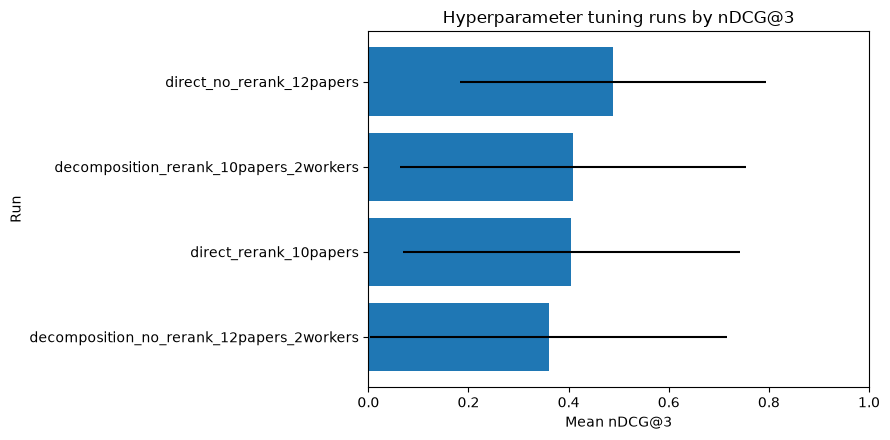

In [17]:
import matplotlib.pyplot as plt

plot_df = overall_summary_df.sort_values("mean_ndcg_at_3", ascending=True)

plt.figure(figsize=(9, 4.5))
plt.barh(plot_df["run_name"], plot_df["mean_ndcg_at_3"], xerr=plot_df["std_ndcg_at_3"])
plt.xlabel("Mean nDCG@3")
plt.ylabel("Run")
plt.title("Hyperparameter tuning runs by nDCG@3")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Export tables

The notebook writes the most useful tables to `OUTPUT_DIR`.

In [19]:
paths = {
    "load_summary": OUTPUT_DIR / "hyperparameter_tuning_load_summary.csv",
    "query_scores": OUTPUT_DIR / "hyperparameter_tuning_query_scores.csv",
    "overall_summary": OUTPUT_DIR / "hyperparameter_tuning_overall_summary.csv",
    "thesis_table": OUTPUT_DIR / "hyperparameter_tuning_thesis_table.csv",
    "by_query_type": OUTPUT_DIR / "hyperparameter_tuning_by_query_type.csv",
    "paired_delta_summary": OUTPUT_DIR / "hyperparameter_tuning_paired_delta_summary.csv",
    "comparison": OUTPUT_DIR / "hyperparameter_tuning_query_comparison.csv",
    "best_run_per_query": OUTPUT_DIR / "hyperparameter_tuning_best_run_per_query.csv",
    "best_run_counts": OUTPUT_DIR / "hyperparameter_tuning_best_run_counts.csv",
    "fallback_diagnostics": OUTPUT_DIR / "hyperparameter_tuning_fallback_diagnostics.csv",
    "fallback_summary": OUTPUT_DIR / "hyperparameter_tuning_fallback_summary.csv",
}

safe_to_csv(load_summary_df, paths["load_summary"])
safe_to_csv(query_score_df, paths["query_scores"])
safe_to_csv(overall_summary_df, paths["overall_summary"])
safe_to_csv(thesis_table_df, paths["thesis_table"])
safe_to_csv(by_query_type_df, paths["by_query_type"])
safe_to_csv(paired_delta_summary_df, paths["paired_delta_summary"])
safe_to_csv(comparison_df, paths["comparison"])
safe_to_csv(best_run_per_query_df, paths["best_run_per_query"])
safe_to_csv(best_run_counts_df, paths["best_run_counts"])
safe_to_csv(fallback_diagnostic_df, paths["fallback_diagnostics"])
safe_to_csv(fallback_summary_df, paths["fallback_summary"])

print("Wrote:")
for name, path in paths.items():
    print(f"- {name}: {path}")

NameError: name 'paired_delta_summary_df' is not defined

## LaTeX table helper

This prints a compact table that can be copied into Overleaf. You may still want to shorten run names manually.

In [20]:
latex_cols = [
    "run_name",
    "n_queries",
    "avg_returned_equipment",
    "mean_ndcg_at_3",
    "std_ndcg_at_3",
    "hit_rate_at_3",
    "must_have_recall_at_3",
    "relevant_recall_at_3",
    "mean_fallback_fraction",
]

latex_df = thesis_table_df[latex_cols].copy()
print(latex_df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{lrrrrrrrr}
\toprule
run_name & n_queries & avg_returned_equipment & mean_ndcg_at_3 & std_ndcg_at_3 & hit_rate_at_3 & must_have_recall_at_3 & relevant_recall_at_3 & mean_fallback_fraction \\
\midrule
direct_no_rerank_12papers & 15 & 2.467 & 0.488 & 0.306 & 0.800 & 0.243 & 0.218 & 0.798 \\
decomposition_rerank_10papers_2workers & 15 & 5.667 & 0.409 & 0.345 & 0.667 & 0.183 & 0.126 & 0.703 \\
direct_rerank_10papers & 15 & 2.067 & 0.406 & 0.337 & 0.600 & 0.183 & 0.119 & 0.787 \\
decomposition_no_rerank_12papers_2workers & 15 & 6.267 & 0.360 & 0.356 & 0.600 & 0.145 & 0.148 & 0.782 \\
\bottomrule
\end{tabular}



## Suggested thesis wording

You can adapt this after running the notebook:

> Hyperparameter settings were compared on the same tuning queries using the same automatic equipment-matching metrics as the final model evaluation. The primary selection metric was `nDCG@3`, because the recommender returns a ranked list and the first few recommendations are most important. `Hit@3`, `Must-have Recall@3`, and `Relevant Recall@3` were used as supporting metrics. Retrieval diagnostics, such as fallback fraction and full-text success fraction, were reported separately to distinguish recommendation quality from document-access limitations.